In [123]:
!hostname

n22.clstr


In [80]:
import pandas as pd
import requests
import io
import numpy as np
import matplotlib.pyplot as plt
import glob
import xarray as xr
import geopandas as gpd
import matplotlib.colors as mcolors
import pandas as pd
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [108]:
import pandas as pd

file_path = '/center1/DYNDOWN/phutton5/ROS/snotel/Creamersfield_snotel_2021-12-01.csv'
df = pd.read_csv(file_path)
df = df.rename(columns={
    'Unnamed: 0': 'site_id',
    'Unnamed: 1': 'date',
    'Unnamed: 2': 'time',
    'Unnamed: 3': 'SWE (in)',
    'Unnamed: 4': 'PREC.I-1 (in)',
    'Unnamed: 5': 'PREC.I-2 (in)',
    'Unnamed: 6': 'Air Temperature (F)'})
df.drop(columns=['Unnamed: 7','Unnamed: 8','Unnamed: 9','Unnamed: 10','Unnamed: 11',
    'Unnamed: 12','Unnamed: 13','Unnamed: 14','Unnamed: 15','Unnamed: 16',
    'Unnamed: 17','Unnamed: 18'], inplace=True)
df = df.dropna()

df["PREC.I-1 (in)"] = pd.to_numeric(df["PREC.I-1 (in)"], errors="coerce")
df["PREC.I-2 (in)"] = pd.to_numeric(df["PREC.I-2 (in)"], errors="coerce")

df["PREC.I-1 (mm)"] = df["PREC.I-1 (in)"] * 25.4
df["PREC.I-2 (mm)"] = df["PREC.I-2 (in)"] * 25.4

df["hourly_PREC.I-1 (mm)"] = df["PREC.I-1 (mm)"].diff().fillna(0)
df["hourly_PREC.I-2 (mm)"] = df["PREC.I-2 (mm)"].diff().fillna(0)


In [109]:
creamerslat=64.52
creamerslon=-147.44

In [112]:
snotel = df.drop(df[df["date"].between("2021-12-01", "2021-12-25")].index)
snotel = df.drop(df[df["date"].between("2021-12-28", "2021-12-31")].index)
snotel["hourly_PREC.I-2 (mm)"] = snotel["hourly_PREC.I-2 (mm)"].clip(lower=0)
snotel["hourly_PREC.I-1 (mm)"] = snotel["hourly_PREC.I-1 (mm)"].clip(lower=0)

In [118]:
snotel

,site_id,date,time,SWE (in),PREC.I-1 (in),PREC.I-2 (in),Air Temperature (F),PREC.I-1 (mm),PREC.I-2 (mm),hourly_PREC.I-1 (mm),hourly_PREC.I-2 (mm)
5,Site Id,Date,Time,WTEQ.I-1 (in),NaN,NaN,TOBS.I-1 (degC),NaN,NaN,0.00,0.000
598,1302,2021-12-26,00:00,3.3,4.3,1.32,-10.6,109.22,33.528,15.24,0.000
599,1302,2021-12-26,01:00,3.3,3.8,1.32,-10.6,96.52,33.528,0.00,0.000
600,1302,2021-12-26,02:00,3.3,3.8,1.32,-10.0,96.52,33.528,0.00,0.000
601,1302,2021-12-26,03:00,3.4,3.8,1.32,-10.0,96.52,33.528,0.00,0.000
602,1302,2021-12-26,04:00,3.5,3.9,1.32,-10.0,99.06,33.528,2.54,0.000
603,1302,2021-12-26,05:00,3.5,3.9,1.32,-10.0,99.06,33.528,0.00,0.000
604,1302,2021-12-26,06:00,3.6,3.9,1.32,-10.0,99.06,33.528,0.00,0.000
605,1302,2021-12-26,07:00,3.7,4.0,1.32,-9.4,101.60,33.528,2.54,0.000
606,1302,2021-12-26,08:00,3.8,4.2,1.32,-7.8,106.68,33.528,5.08,0.000


In [ ]:
hourly=[df["hourly_PREC.I-1 (mm)"]]

[5       0.00
 598    15.24
 599     0.00
 600     0.00
 601     0.00
 602     2.54
 603     0.00
 604     0.00
 605     2.54
 606     5.08
 607     2.54
 608     2.54
 609     0.00
 610     2.54
 611     2.54
 612     0.00
 613     2.54
 614     2.54
 615     2.54
 616     2.54
 617     2.54
 618     2.54
 619    10.16
 620     0.00
 621     2.54
 Name: hourly_PREC.I-1 (mm), dtype: float64]

In [85]:
winter_months = [11, 12, 1, 2, 3]
#Rick thoman data 
#https://docs.google.com/spreadsheets/d/1MUeq6N2F8OGBeYOa226iCbaVQBOxj01ibf5IwYqt5nI/edit?gid=0#gid=0
url = "https://docs.google.com/spreadsheets/d/1MUeq6N2F8OGBeYOa226iCbaVQBOxj01ibf5IwYqt5nI/export?format=csv&id=1MUeq6N2F8OGBeYOa226iCbaVQBOxj01ibf5IwYqt5nI&gid=0"
rick_df = pd.read_csv(url)

rick_df['Year'] = pd.to_numeric(rick_df['Year'], errors='coerce')
rick_df['Month'] = pd.to_numeric(rick_df['Month'], errors='coerce')
rick_df['Rain Precip Amount (mm)'] = pd.to_numeric(rick_df['Rain Precip Amount (mm)'],errors='coerce')

rick_season_df = rick_df.loc[rick_df['Month'].isin([11, 12, 1, 2, 3])].copy()
season_start = rick_season_df['Year'].where(~rick_season_df['Month'].isin([1, 2, 3]),rick_season_df['Year'] - 1)
season_end = season_start + 1

rick_season_df['season'] = (season_start.astype(int).astype(str)+ '-'+ season_end.astype(int).astype(str))
rick_season_df['season_sum_rain_mm'] = (rick_season_df.groupby('season')['Rain Precip Amount (mm)'].transform('sum'))

rick_monthly = rick_season_df.groupby('Month')['Rain Precip Amount (mm)'].sum(numeric_only=True)
rick_monthly=rick_monthly.reindex(winter_months).values #correct order 

rick_dec_2021=rick_season_df[rick_season_df['Year']==2021]
rick_dec_2021
rick_dec_2021_sum= rick_dec_2021['season_sum_rain_mm'].sum()
rick_dec_2021_sum

38.1

ASOS

In [119]:
website='https://mesonet.agron.iastate.edu/cgi-bin/request/asos.py?network=AK_ASOS&station=PAFA&data=tmpc&data=p01m&data=wxcodes&data=snowdepth&year1=1949&month1=10&day1=1&year2=2022&month2=12&day2=23&tz=Etc%2FUTC&format=onlycomma&latlon=yes&elev=no&missing=M&trace=T&direct=no&report_type=3&report_type=4'
#https://mesonet.agron.iastate.edu/cgi-bin/request/asos.py?network=AK_ASOS&station=PAFA&data=tmpc&data=p01m&data=wxcodes&data=snowdepth&year1=1950&month1=1&day1=1&year2=2023&month2=12&day2=9&tz=America%2FAnchorage&format=onlycomma&latlon=yes&elev=no&missing=M&trace=T&direct=no&report_type=3&report_type=4'
response = requests.get(website)
if response.status_code == 200:
    data = io.StringIO(response.text)
    df = pd.read_csv(data, comment="#")  
    print(df.head())
else:
    print("Error:", response.status_code)

  station             valid       lon      lat  tmpc p01m wxcodes snowdepth
0    PAFA  1949-10-01 00:00 -147.8761  64.8039  6.67    M       M         M
1    PAFA  1949-10-01 01:00 -147.8761  64.8039  6.67    M       M         M
2    PAFA  1949-10-01 02:00 -147.8761  64.8039  6.11    M       M         M
3    PAFA  1949-10-01 03:00 -147.8761  64.8039  6.11    M       M         M
4    PAFA  1949-10-01 04:00 -147.8761  64.8039  5.00    M       M         M


In [120]:
df['valid'] = pd.to_datetime(df['valid'])
df['month'] = df['valid'].dt.month
df['date'] = df['valid'].dt.date
df['time'] = df['valid'].dt.time
#df['tmpc']
#df = df.drop(columns=['column_name'])
winter_df = df[df['month'].isin([11, 12, 1, 2, 3])] #filter to only keep the ROS months 

winter_df['date'] = pd.to_datetime(winter_df['date'])
year = winter_df['date'].dt.year
month = winter_df['date'].dt.month
season_start = year.where(~month.isin([1, 2, 3]), year - 1)
season_end = season_start + 1
winter_df['season'] = season_start.astype(str) + '-' + season_end.astype(str)

#filter to only when RA is present 
mask = winter_df['wxcodes'].str.contains('RA', na=False)
rain_and_mixed_df = winter_df[mask]
rain_and_mixed_df['p01m'] = rain_and_mixed_df['p01m'].replace('M', np.nan) 
rain_and_mixed_df['p01m'] = rain_and_mixed_df['p01m'].replace('T', np.nan) 
rain_and_mixed_df['p01m'] = pd.to_numeric(rain_and_mixed_df['p01m'], errors='coerce')

/center1/DYNDOWN/phutton5/VSCODE_dump/ipykernel_4158311/854007281.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  winter_df['date'] = pd.to_datetime(winter_df['date'])
/center1/DYNDOWN/phutton5/VSCODE_dump/ipykernel_4158311/854007281.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  winter_df['season'] = season_start.astype(str) + '-' + season_end.astype(str)
/center1/DYNDOWN/phutton5/VSCODE_dump/ipykernel_4158311/854007281.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a sl

In [121]:
dec_df=rain_and_mixed_df[rain_and_mixed_df['month']==12]
dec_2021=dec_df[dec_df['season']=='2021-2022']
#Icemaggeddon December 26-28 2021
dec_df=rain_and_mixed_df[rain_and_mixed_df['month']==12]
dec_2021=dec_df[dec_df['season']=='2021-2022']
dec_2021=dec_2021.drop(dec_2021[dec_2021['valid']==pd.Timestamp('2021-12-19 13:48:00')].index)
dec_2021=dec_2021.drop(dec_2021[dec_2021['valid']==pd.Timestamp('2021-12-19 13:53:00')].index)
dec_2021=dec_2021.drop(dec_2021[dec_2021['valid']==pd.Timestamp('2021-12-28 18:21:00')].index)
dec_2021=dec_2021.drop(dec_2021[dec_2021['valid']==pd.Timestamp('2021-12-29 09:53:00')].index)
dec_2021=dec_2021.drop(dec_2021[dec_2021['valid']==pd.Timestamp('2021-12-29 10:00:00')].index)

asos_precip_sum_dec_2021=dec_2021['p01m'].sum()
asos_precip_sum_dec_2021

36.82

In [122]:
def getXY(lat, lon, dataarray):
    abslat = np.abs(dataarray.XLAT-lat)
    abslon = np.abs(dataarray.XLONG-lon)
    d = abslon**2 + abslat**2
    flat_index = np.argmin(d.values)
    yloc, xloc = np.unravel_index(flat_index, d.shape)
    return xloc, yloc

In [ ]:
regridded_era5_path='/center1/DYNDOWN/phutton5/ROS/All_of_AK/All_of_AK_netcdf_files/ROS_December_2021_nearest_regridded_ERA5_31kmto4km_ROS.nc'
regridded_era5=xr.open_dataset(regridded_era5_path)

regridded_era5=regridded_era5.sel(time=slice("2021-12-26", "2021-12-27 23:59:59"))

#ERA5  4km
era5_4km='/center1/DYNDOWN/phutton5/ROS/All_of_AK/All_of_AK_netcdf_files/ROS_Dec2021_hourly_4km.nc' 
era5_4km = xr.open_mfdataset(era5_4km,combine="by_coords", parallel=True)

era5_4km = era5_4km.sel(Time=slice("2021-12-26", "2021-12-27 23:59:59"))

lat=era5_4km['XLAT'].values
lon=era5_4km['XLONG'].values


In [131]:
pafa_lat=64.8039
pafa_lon=-147.8761

In [135]:
x_idx, y_idx = getXY(creamerslat, creamerslon, era5_4km)
#x_idx, y_idx = getXY(pafa_lat, pafa_lon, era5_4km)
nearest_lat = era5_4km.XLAT[y_idx, x_idx]
nearest_lon = era5_4km.XLONG[y_idx, x_idx]

cell4km = era5_4km.isel(
    south_north=y_idx,
    west_east=x_idx)

cell_regrid=regridded_era5.isel(
    south_north=y_idx,
    west_east=x_idx)


cell_regrid_sum=cell_regrid['rain_during_ros'].sum()
cell4km_sum=cell4km['RAIN'].sum()

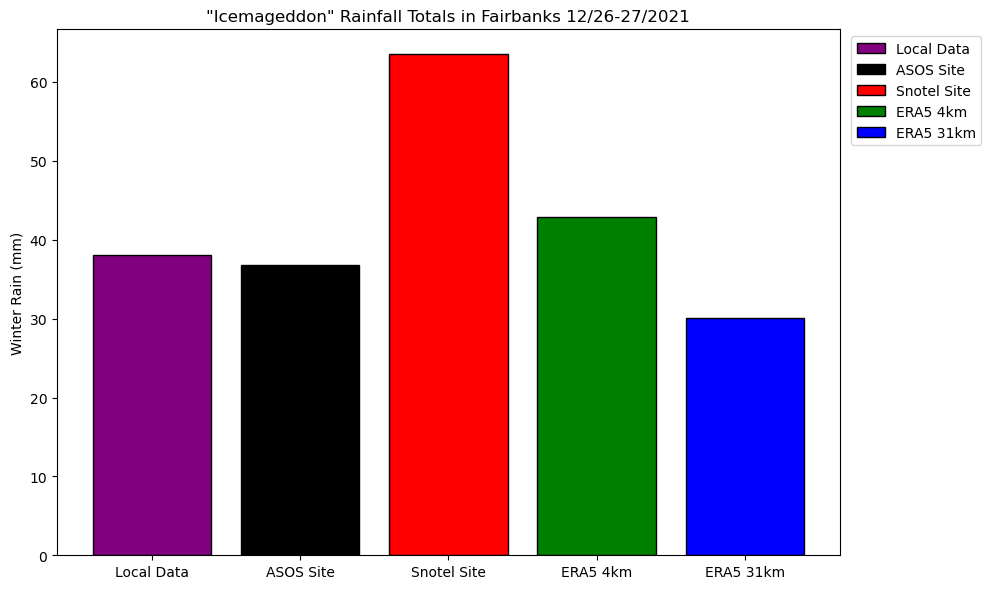

In [136]:
data_labels=['Local Data','ASOS Site','Snotel Site','ERA5 4km','ERA5 31km']
x = np.arange(len(data_labels))
fig, ax = plt.subplots(figsize=(10,6))
data=[rick_dec_2021_sum, asos_precip_sum_dec_2021, hourly, cell4km_sum, cell_regrid_sum]
data = [
    np.sum(rick_dec_2021_sum),
    np.sum(asos_precip_sum_dec_2021),
    np.sum(hourly),
    np.sum(cell4km_sum),
    np.sum(cell_regrid_sum)
]

plt.bar(data_labels, data, color=['purple','black','red','green','blue'], edgecolor='black', label=data_labels)
ax.set_xticks(x)
ax.set_xticklabels(data_labels)
ax.set_ylabel('Winter Rain (mm)')
ax.set_title('"Icemageddon" Rainfall Totals in Fairbanks 12/26-27/2021')
ax.legend(loc='upper right', bbox_to_anchor=(1.19, 1))
plt.tight_layout()
plt.show()

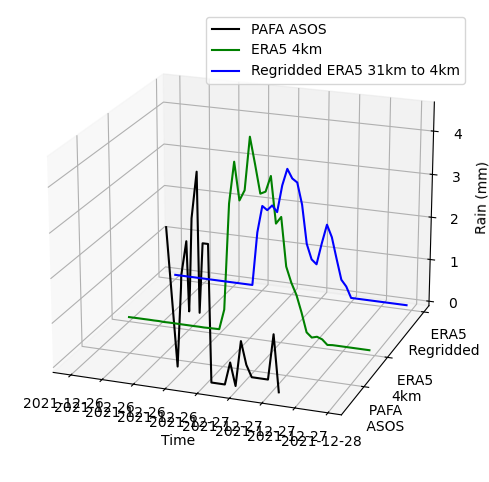

In [130]:
import matplotlib.dates as mdates

# Convert datetime columns to matplotlib float dates
time1 = mdates.date2num(dec_2021['valid'])
time2 = mdates.date2num(cell4km['Time'])
time3 = mdates.date2num(cell_regrid['time'])
#timehourly = mdates.date2num(snotel['date'])
timehourly=snotel['date']
fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(111, projection='3d')

# z positions for lines
z1, z2, z3 = 0, 0.5, 1

ax.plot(time1, dec_2021['p01m'].fillna(0), zs=z1, zdir='y', color='black', label='PAFA ASOS')
#ax.plot(timehourly, hourly, zs=0.1, zdir='y', color='red', label='Snotel Site')
ax.plot(time2, cell4km['RAIN'].fillna(0), zs=z2, zdir='y', color='green', label='ERA5 4km')
ax.plot(time3, cell_regrid['rain_during_ros'].fillna(0), zs=z3, zdir='y', color='blue', label='Regridded ERA5 31km to 4km')

ax.set_xlabel('Time')
ax.set_zlabel('Rain (mm)')

ax.set_yticks([0.2, 0.5, 1])
ax.set_yticklabels(['  PAFA \n ASOS','     ERA5 \n4km','    ERA5 \n Regridded'])
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

ax.view_init(elev=20, azim=-70)
plt.legend()
plt.show()